<a href="https://colab.research.google.com/github/rishitmiglani2006-web/Gender_classification/blob/main/Gender_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision
!pip install opencv-python

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [ ]:
!file /content/archive.zip

/content/archive.zip: cannot open `/content/archive.zip' (No such file or directory)


In [ ]:
import os

print("Size:", os.path.getsize("/content/archive.zip") / (1024*1024), "MB")

FileNotFoundError: [Errno 2] No such file or directory: '/content/archive.zip'

In [ ]:
!unzip -q /content/archive.zip -d /content/dataset

In [ ]:
import os

print(os.listdir('/content/dataset'))

['utkface_aligned_cropped', 'UTKFace', 'crop_part1']


In [ ]:
print(os.listdir('/content/dataset'))

['utkface_aligned_cropped', 'UTKFace', 'crop_part1']


In [ ]:
!find /content/dataset -type f | head -10

/content/dataset/utkface_aligned_cropped/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_0_0_20170112215240346.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170110183726390.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170112213001988.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170112213303693.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170112215032192.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170117195420803.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_0_20170119212053665.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_2_20170105174847679.jpg.chip.jpg
/content/dataset/utkface_aligned_cropped/UTKFace/100_1_2_20170112213615815.jpg.chip.jpg


In [ ]:
!find /content/dataset -type f | wc -l

66976


In [ ]:
dataset_path = "/content/dataset/utkface_aligned_cropped/UTKFace"

In [ ]:
import os

files = os.listdir(dataset_path)

print("Total images:", len(files))
print(files[:5])

Total images: 23708
['47_1_0_20170119192708105.jpg.chip.jpg', '29_1_0_20170117005833085.jpg.chip.jpg', '14_0_0_20170110232633429.jpg.chip.jpg', '18_1_0_20170109212906609.jpg.chip.jpg', '26_0_1_20170116204840434.jpg.chip.jpg']


In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = os.path.join(dataset_path, files[0])

image = cv2.imread(image_path)

print(image.shape)

(200, 200, 3)


In [ ]:
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

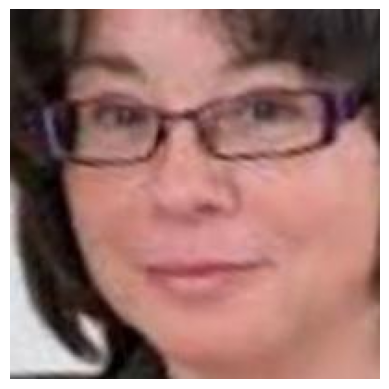

In [ ]:
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

In [ ]:
def get_gender(filename):
    return int(filename.split("_")[1])

In [ ]:
for i in range(5):
    file = files[i]

    gender = get_gender(file)

    print(file)
    print("Gender:", gender)
    print()

47_1_0_20170119192708105.jpg.chip.jpg
Gender: 1

29_1_0_20170117005833085.jpg.chip.jpg
Gender: 1

14_0_0_20170110232633429.jpg.chip.jpg
Gender: 0

18_1_0_20170109212906609.jpg.chip.jpg
Gender: 1

26_0_1_20170116204840434.jpg.chip.jpg
Gender: 0



In [ ]:
labels = []

for file in files:
    labels.append(get_gender(file))

In [ ]:
print(labels[:10])

[1, 1, 0, 1, 0, 1, 0, 0, 1, 1]


In [ ]:
print(files[:5])
print(labels[:5])

['47_1_0_20170119192708105.jpg.chip.jpg', '29_1_0_20170117005833085.jpg.chip.jpg', '14_0_0_20170110232633429.jpg.chip.jpg', '18_1_0_20170109212906609.jpg.chip.jpg', '26_0_1_20170116204840434.jpg.chip.jpg']
[1, 1, 0, 1, 0]


In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [ ]:
import cv2
import os

image_path = os.path.join(dataset_path, files[0])

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

tensor_image = transform(image)

print(tensor_image.shape)

torch.Size([3, 128, 128])


In [ ]:
from torch.utils.data import Dataset
import torch

class GenderDataset(Dataset):

    def __init__(self, folder, transform=None):
        self.folder = folder
        self.files = os.listdir(folder)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        image_path = os.path.join(
            self.folder,
            filename
        )

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        gender = int(
            filename.split("_")[1]
        )

        if self.transform:
            image = self.transform(image)

        return image, gender

In [ ]:
dataset = GenderDataset(
    dataset_path,
    transform=transform
)

In [ ]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([3, 128, 128])
1


In [ ]:
print(tensor_image.shape)

torch.Size([3, 128, 128])


In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
images, labels = next(iter(loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


In [ ]:
torch.Size([32, 3, 128, 128])
torch.Size([32])

torch.Size([32])

In [ ]:
import tensorflow as tf

class CustomLinearLayer(tf.keras.layers.Layer):

    def __init__(self, units):
        super().__init__()
        self.units = units

    def build(self, input_shape):

        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

In [ ]:
sample = tf.random.normal((5, 100))

layer = CustomLinearLayer(50)

output = layer(sample)

print(output.shape)

(5, 50)


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential

model = Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    CustomLinearLayer(128),

    layers.Activation('relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_linear_layer_1           │ (None, 128)            │     3,211,392 │
│ (CustomLinearLayer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,312,961 (12.64 MB)

 Trainable params: 3,312,961 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

NameError: name 'train_dataset' is not defined

In [ ]:
!file /content/archive.zip

/content/archive.zip: cannot open `/content/archive.zip' (No such file or directory)


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [21]:
import os

print(os.listdir('/content'))

['.config', 'archive.zip', 'sample_data']


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
!mkdir -p "/content/drive/MyDrive/GenderProject"

In [24]:
!cp /content/archive.zip "/content/drive/MyDrive/GenderProject/"

In [25]:
print(os.listdir('/content'))

['.config', 'drive', 'archive.zip', 'sample_data']


In [26]:
!unzip -q /content/archive.zip -d /content/dataset

[/content/archive.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/archive.zip or
        /content/archive.zip.zip, and cannot find /content/archive.zip.ZIP, period.


In [28]:
!unzip -oq /content/archive.zip -d /content/dataset

In [29]:
import os

print(os.path.exists('/content/dataset'))

True


In [30]:
print(os.listdir('/content/dataset'))

['utkface_aligned_cropped', 'crop_part1', 'UTKFace']


In [31]:
dataset_path = "/content/dataset/utkface_aligned_cropped/UTKFace"

In [32]:
import os

files = os.listdir(dataset_path)

print("Total Images:", len(files))
print(files[:5])

Total Images: 23708
['12_1_1_20170112213303693.jpg.chip.jpg', '28_0_1_20170112211822909.jpg.chip.jpg', '45_0_2_20170117183529862.jpg.chip.jpg', '2_0_4_20161221202147913.jpg.chip.jpg', '9_0_0_20170110220134026.jpg.chip.jpg']


In [33]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [34]:
from torch.utils.data import Dataset
import cv2
import torch
import os

class GenderDataset(Dataset):

    def __init__(self, folder, transform=None):
        self.folder = folder
        self.files = os.listdir(folder)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        image_path = os.path.join(
            self.folder,
            filename
        )

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        gender = int(
            filename.split("_")[1]
        )

        if self.transform:
            image = self.transform(image)

        return image, gender

In [35]:
dataset = GenderDataset(
    dataset_path,
    transform=transform
)

In [36]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([3, 128, 128])
1


In [38]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [39]:
images, labels = next(iter(loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


In [40]:
print(image.shape)
print(label)

print(images.shape)
print(labels.shape)

torch.Size([3, 128, 128])
1
torch.Size([32, 3, 128, 128])
torch.Size([32])


In [41]:
import tensorflow as tf

class CustomLinearLayer(tf.keras.layers.Layer):

    def __init__(self, units):
        super().__init__()
        self.units = units

    def build(self, input_shape):

        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

In [42]:
sample = tf.random.normal((5, 100))

layer = CustomLinearLayer(50)

output = layer(sample)

print(output.shape)

(5, 50)


In [43]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential

model = Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    CustomLinearLayer(128),

    layers.Activation('relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_linear_layer_3           │ (None, 128)            │     3,211,392 │
│ (CustomLinearLayer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,312,961 (12.64 MB)

 Trainable params: 3,312,961 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [47]:
print("train_dataset" in globals())
print("train_ds" in globals())
print("val_dataset" in globals())
print("val_ds" in globals())

False
False
False
False


In [48]:
import os

print(os.listdir('/content'))

['.config', 'dataset', 'drive', 'archive.zip', 'sample_data']


In [49]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)

/content/dataset
/content/dataset/utkface_aligned_cropped
/content/dataset/utkface_aligned_cropped/crop_part1
/content/dataset/utkface_aligned_cropped/UTKFace
/content/dataset/crop_part1
/content/dataset/UTKFace


In [51]:
!find /content/dataset -type d

/content/dataset
/content/dataset/utkface_aligned_cropped
/content/dataset/utkface_aligned_cropped/crop_part1
/content/dataset/utkface_aligned_cropped/UTKFace
/content/dataset/crop_part1
/content/dataset/UTKFace


In [52]:
import os

print(len(os.listdir("/content/dataset/UTKFace")))
print(os.listdir("/content/dataset/UTKFace")[:5])

23708
['12_1_1_20170112213303693.jpg.chip.jpg', '28_0_1_20170112211822909.jpg.chip.jpg', '45_0_2_20170117183529862.jpg.chip.jpg', '2_0_4_20161221202147913.jpg.chip.jpg', '9_0_0_20170110220134026.jpg.chip.jpg']


In [53]:
image_paths = []
labels = []

for file in files:

    try:
        gender = int(file.split('_')[1])

        image_paths.append(
            os.path.join(folder, file)
        )

        labels.append(gender)

    except:
        pass

In [54]:
print(len(image_paths))
print(len(labels))
print(labels[:10])

0
0
[]


In [56]:
import os

folder = "/content/dataset/UTKFace"

files = os.listdir(folder)

print("Number of files:", len(files))
print(files[:10])

Number of files: 23708
['12_1_1_20170112213303693.jpg.chip.jpg', '28_0_1_20170112211822909.jpg.chip.jpg', '45_0_2_20170117183529862.jpg.chip.jpg', '2_0_4_20161221202147913.jpg.chip.jpg', '9_0_0_20170110220134026.jpg.chip.jpg', '1_0_2_20161219201319628.jpg.chip.jpg', '92_1_0_20170110175809576.jpg.chip.jpg', '35_0_1_20170113183259413.jpg.chip.jpg', '25_1_4_20161220222242243.jpg.chip.jpg', '38_1_3_20170119163208659.jpg.chip.jpg']


In [57]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    if len(files) > 0:
        print(root)
        print("Files:", len(files))
        print("Sample:", files[:3])
        print("-"*50)

/content/dataset/utkface_aligned_cropped/crop_part1
Files: 9780
Sample: ['2_0_4_20161221202147913.jpg.chip.jpg', '9_0_0_20170110220134026.jpg.chip.jpg', '1_0_2_20161219201319628.jpg.chip.jpg']
--------------------------------------------------
/content/dataset/utkface_aligned_cropped/UTKFace
Files: 23708
Sample: ['12_1_1_20170112213303693.jpg.chip.jpg', '28_0_1_20170112211822909.jpg.chip.jpg', '45_0_2_20170117183529862.jpg.chip.jpg']
--------------------------------------------------
/content/dataset/crop_part1
Files: 9780
Sample: ['2_0_4_20161221202147913.jpg.chip.jpg', '9_0_0_20170110220134026.jpg.chip.jpg', '1_0_2_20161219201319628.jpg.chip.jpg']
--------------------------------------------------
/content/dataset/UTKFace
Files: 23708
Sample: ['12_1_1_20170112213303693.jpg.chip.jpg', '28_0_1_20170112211822909.jpg.chip.jpg', '45_0_2_20170117183529862.jpg.chip.jpg']
--------------------------------------------------


In [58]:
import os

folder = "/content/dataset/UTKFace"

image_paths = []
labels = []

for file in os.listdir(folder):

    try:
        gender = int(file.split('_')[1])

        image_paths.append(
            os.path.join(folder, file)
        )

        labels.append(gender)

    except:
        pass

print("Images:", len(image_paths))
print("Labels:", len(labels))
print("First Label:", labels[0])

Images: 23708
Labels: 23708
First Label: 1


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42
)

print(len(X_train))
print(len(X_val))

18966
4742


In [60]:
import tensorflow as tf

IMG_SIZE = (128,128)

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = image / 255.0

    return image, label

In [61]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(32)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

In [62]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(32)

val_ds = val_ds.prefetch(
    tf.data.AUTOTUNE
)

In [63]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 128, 128, 3)
(32,)


In [64]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [65]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 401s 672ms/step - accuracy: 0.8049 - loss: 0.4101 - val_accuracy: 0.8560 - val_loss: 0.3367
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 430s 652ms/step - accuracy: 0.8728 - loss: 0.2937 - val_accuracy: 0.8189 - val_loss: 0.3872
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 387s 652ms/step - accuracy: 0.8915 - loss: 0.2548 - val_accuracy: 0.8574 - val_loss: 0.3267
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 385s 650ms/step - accuracy: 0.9066 - loss: 0.2242 - val_accuracy: 0.8741 - val_loss: 0.3030
Epoch 5/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 386s 652ms/step - accuracy: 0.9190 - loss: 0.1944 - val_accuracy: 0.8872 - val_loss: 0.2902
Epoch 6/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 388s 655ms/step - accuracy: 0.9297 - loss: 0.1702 - val_accuracy: 0.8872 - val_loss: 0.2812
Epoch 7/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 372s 628ms/step - accuracy: 0.9422 - loss: 0.1467 - val_accuracy: 0.8941 - val_loss: 0.2941
Epoch 8/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 399s 657ms/step - accuracy: 0.9491 -

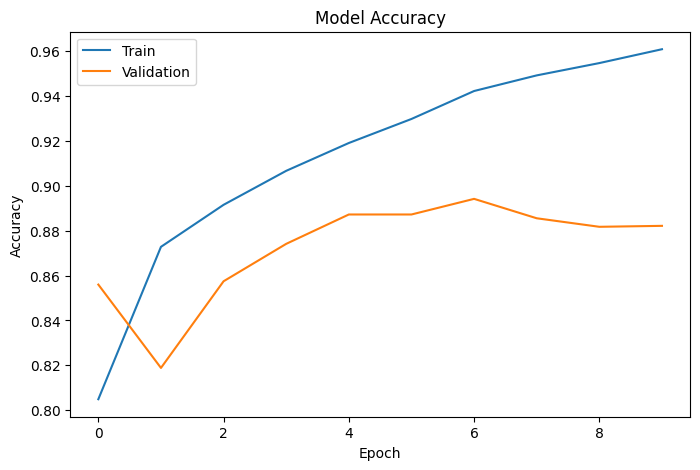

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

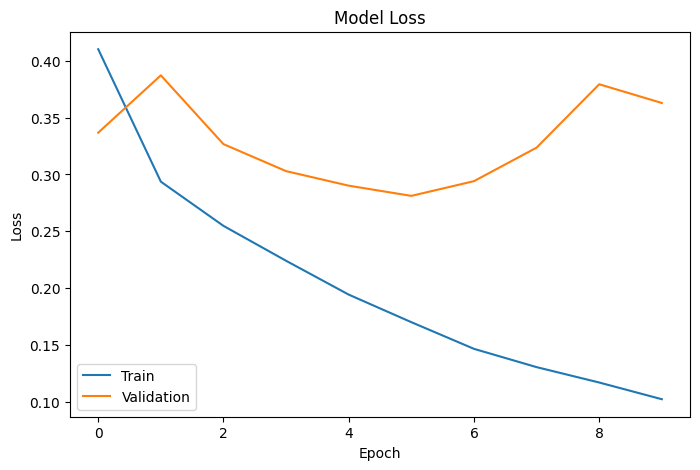

In [67]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [68]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

149/149 ━━━━━━━━━━━━━━━━━━━━ 27s 177ms/step - accuracy: 0.8821 - loss: 0.3629
Validation Loss: 0.36286503076553345
Validation Accuracy: 0.8821172714233398


In [69]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[2117  300]
 [ 259 2066]]


In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      2417
           1       0.87      0.89      0.88      2325

    accuracy                           0.88      4742
   macro avg       0.88      0.88      0.88      4742
weighted avg       0.88      0.88      0.88      4742



In [71]:
model.save("gender_classifier.keras")

In [72]:
from google.colab import files
files.download("gender_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
import os

folder = "/content/dataset/UTKFace"

test_image = os.path.join(
    folder,
    os.listdir(folder)[0]
)

print(test_image)

/content/dataset/UTKFace/12_1_1_20170112213303693.jpg.chip.jpg


In [75]:
img = tf.keras.utils.load_img(
    test_image,
    target_size=(128,128)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = tf.expand_dims(img_array, 0)

prediction = model.predict(img_array)

print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction: [[0.9992337]]


In [76]:
if prediction[0][0] > 0.5:
    print("Predicted Gender: Female")
else:
    print("Predicted Gender: Male")

Predicted Gender: Female


In [77]:
filename = os.path.basename(test_image)

actual_gender = int(filename.split('_')[1])

print("Actual Gender:", "Female" if actual_gender == 1 else "Male")

Actual Gender: Female


In [78]:
from google.colab import files

uploaded = files.upload()

Saving Rishit Photograph (1).jpg to Rishit Photograph (1).jpg


In [79]:
import tensorflow as tf

img = tf.keras.utils.load_img(
    "Rishit Photograph (1).jpg",
    target_size=(128,128)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0

# Add batch dimension
img_array = tf.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 128, 128, 3)


In [80]:
prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Raw Prediction: [[0.99950135]]


In [81]:
score = prediction[0][0]

if score > 0.5:
    print(f"Predicted Gender: Female ({score*100:.2f}% confidence)")
else:
    print(f"Predicted Gender: Male ({(1-score)*100:.2f}% confidence)")

Predicted Gender: Female (99.95% confidence)


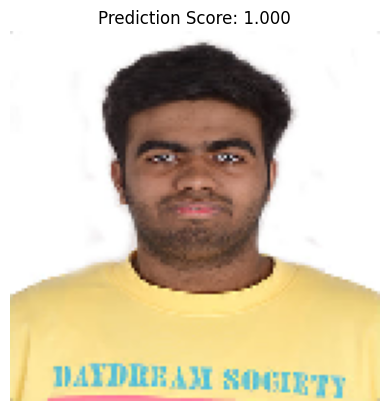

In [82]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction Score: {score:.3f}")
plt.axis("off")
plt.show()

In [84]:
print(labels[:20])

tf.Tensor([0 0 1 0 1 0], shape=(6,), dtype=int32)


In [85]:
for i in range(10):
    path = image_paths[i]

    img = tf.keras.utils.load_img(path, target_size=(128,128))
    arr = tf.keras.utils.img_to_array(img)/255.0
    arr = tf.expand_dims(arr, 0)

    pred = model.predict(arr, verbose=0)[0][0]

    actual = int(os.path.basename(path).split('_')[1])

    print(
        "Actual:",
        "Female" if actual==1 else "Male",
        "| Pred:",
        "Female" if pred>0.5 else "Male",
        "| Score:", pred
    )

Actual: Female | Pred: Female | Score: 0.9992337
Actual: Male | Pred: Male | Score: 2.1537612e-07
Actual: Male | Pred: Male | Score: 0.021254716
Actual: Male | Pred: Male | Score: 0.000120388766
Actual: Male | Pred: Male | Score: 0.05398626
Actual: Male | Pred: Male | Score: 0.27325898
Actual: Female | Pred: Female | Score: 0.8167446
Actual: Male | Pred: Male | Score: 1.5868029e-08
Actual: Female | Pred: Female | Score: 0.99443597
Actual: Female | Pred: Female | Score: 0.99800533


In [86]:
correct = 0
total = 20

for images, labels in val_ds.take(1):

    preds = model.predict(images, verbose=0)

    for i in range(total):

        pred_gender = 1 if preds[i][0] > 0.5 else 0
        actual_gender = int(labels[i])

        if pred_gender == actual_gender:
            correct += 1

        print(
            f"Actual={actual_gender} "
            f"Pred={pred_gender} "
            f"Score={preds[i][0]:.4f}"
        )

print("Accuracy:", correct/total)

Actual=0 Pred=0 Score=0.0000
Actual=0 Pred=0 Score=0.0011
Actual=0 Pred=0 Score=0.0000
Actual=0 Pred=1 Score=0.6184
Actual=0 Pred=0 Score=0.0000
Actual=1 Pred=1 Score=0.7050
Actual=0 Pred=0 Score=0.3906
Actual=1 Pred=1 Score=0.9996
Actual=0 Pred=0 Score=0.0013
Actual=1 Pred=1 Score=0.9994
Actual=1 Pred=1 Score=0.9998
Actual=1 Pred=0 Score=0.2353
Actual=1 Pred=1 Score=0.9759
Actual=0 Pred=0 Score=0.0000
Actual=1 Pred=1 Score=0.9932
Actual=1 Pred=1 Score=0.9998
Actual=0 Pred=0 Score=0.0000
Actual=0 Pred=1 Score=0.9990
Actual=0 Pred=1 Score=0.9858
Actual=1 Pred=1 Score=0.9984
Accuracy: 0.8


In [87]:
female_count = 0
male_count = 0

for images, labels in val_ds:

    preds = model.predict(images, verbose=0)

    female_count += (preds > 0.5).sum()
    male_count += (preds <= 0.5).sum()

print("Female predictions:", female_count)
print("Male predictions:", male_count)

Female predictions: 2366
Male predictions: 2376


In [88]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[2117  300]
 [ 259 2066]]


In [89]:
from google.colab import files

uploaded = files.upload()

Saving Test image 1.jpg to Test image 1.jpg


In [90]:
import tensorflow as tf

img = tf.keras.utils.load_img(
    "Rishit Photograph (1).jpg",
    target_size=(128,128)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0

# Add batch dimension
img_array = tf.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 128, 128, 3)
